Imports.

In [ ]:
import os, zipfile, io, requests, numpy as np, pandas as pd, matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import os, zipfile, requests, shutil

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)
plt.rcParams['figure.dpi'] = 120


Using device: cuda


We are going to use gpu to make training faster.

Now, download the dataset using url and extract data. Follow the comments to understand the function of each block.

In [ ]:
URL = "https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip"
root = "/content" if os.path.isdir("/content") else "."
zip_path = os.path.join(root, "UCI_HAR.zip")
data_dir = os.path.join(root, "UCI_HAR_Dataset")
tmp_extract_dir = os.path.join(root, "UCI_HAR_tmp") # Initial temporary extraction directory
final_dataset_extract_dir = os.path.join(root, "UCI_HAR_final_extract") # New temporary directory for the actual dataset content

if not os.path.exists(data_dir):
    print("Downloading UCI HAR dataset...")
    r = requests.get(URL, timeout=60)
    r.raise_for_status()
    with open(zip_path, "wb") as f:
        f.write(r.content)

    # Ensure tmp_extract_dir is clean and exists
    if os.path.exists(tmp_extract_dir):
        shutil.rmtree(tmp_extract_dir)
    os.makedirs(tmp_extract_dir)

    # Ensure final_dataset_extract_dir is clean and exists
    if os.path.exists(final_dataset_extract_dir):
        shutil.rmtree(final_dataset_extract_dir)
    os.makedirs(final_dataset_extract_dir)

    # First extraction: Extract the downloaded zip
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(tmp_extract_dir)

    inner_zip_path = os.path.join(tmp_extract_dir, "UCI HAR Dataset.zip")

    if os.path.exists(inner_zip_path):
        print("Found nested 'UCI HAR Dataset.zip'. Extracting second level...")
        with zipfile.ZipFile(inner_zip_path, "r") as inner_z:
            inner_z.extractall(final_dataset_extract_dir)
        # Now, the actual dataset content should be in final_dataset_extract_dir, and we search there
        search_dir = final_dataset_extract_dir
    else:
        # If no inner zip, the dataset content is directly in tmp_extract_dir
        search_dir = tmp_extract_dir

    extracted_contents = os.listdir(search_dir)
    dataset_source_path = None

    if "UCI HAR Dataset" in extracted_contents:
        candidate_path = os.path.join(search_dir, "UCI HAR Dataset")
        if os.path.isdir(candidate_path):
            dataset_source_path = candidate_path

    if dataset_source_path:
        # Move the dataset to its final location
        shutil.move(dataset_source_path, data_dir)
        # Verify it exists after move
        if not os.path.isdir(data_dir):
            raise FileNotFoundError(f"Failed to move dataset to '{data_dir}'. Destination not found after move operation.")
        print("Dataset ready at:", data_dir)
    else:
        raise FileNotFoundError(f"Could not locate the UCI HAR Dataset folder within '{search_dir}'. "
                                f"Contents found: {extracted_contents}")

    # Clean up temporary directories
    if os.path.exists(tmp_extract_dir):
        shutil.rmtree(tmp_extract_dir)
    if os.path.exists(final_dataset_extract_dir):
        shutil.rmtree(final_dataset_extract_dir)

else:
    print("Dataset already exists at:", data_dir)

classes = ["WALKING","WALKING_UPSTAIRS","WALKING_DOWNSTAIRS","SITTING","STANDING","LAYING"]
print("Classes:", classes)

Dataset already exists at: /content/UCI_HAR_Dataset
Classes: ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 'SITTING', 'STANDING', 'LAYING']


Now, we are going to prepare the data as per our need. The dataset gives separate train and test file for signals and labels.

In [ ]:
def _read_signals(folder):
    signal_names = [
        "body_acc_x_", "body_acc_y_", "body_acc_z_",
        "body_gyro_x_", "body_gyro_y_", "body_gyro_z_",
        "total_acc_x_", "total_acc_y_", "total_acc_z_",
    ]
    split = os.path.basename(folder)  # 'train' or 'test'
    all_signals = []
    for name in signal_names:
        path = os.path.join(folder, "Inertial Signals", name + split + ".txt")
        with open(path, 'r') as f:
            data = [list(map(float, line.strip().split())) for line in f]
        arr = np.asarray(data, dtype=np.float32)  # [N, 128]
        all_signals.append(arr[:, None, :])
    X = np.concatenate(all_signals, axis=1)  # [N, 9, 128]
    return X

def _read_labels(path):
    y = np.loadtxt(path, dtype=int) - 1  # 1..6 -> 0..5
    return y

train_dir = os.path.join(data_dir, "train")
test_dir  = os.path.join(data_dir, "test")

X_train = _read_signals(train_dir)
X_test  = _read_signals(test_dir)

y_train = _read_labels(os.path.join(train_dir, "y_train.txt"))
y_test  = _read_labels(os.path.join(test_dir, "y_test.txt"))

X_train.shape, X_test.shape, y_train.shape, y_test.shape


((7352, 9, 128), (2947, 9, 128), (7352,), (2947,))

Plot one sample to visualize the signals of different channels. We are plotting three channels here for simplicity. You can plot other channels too.

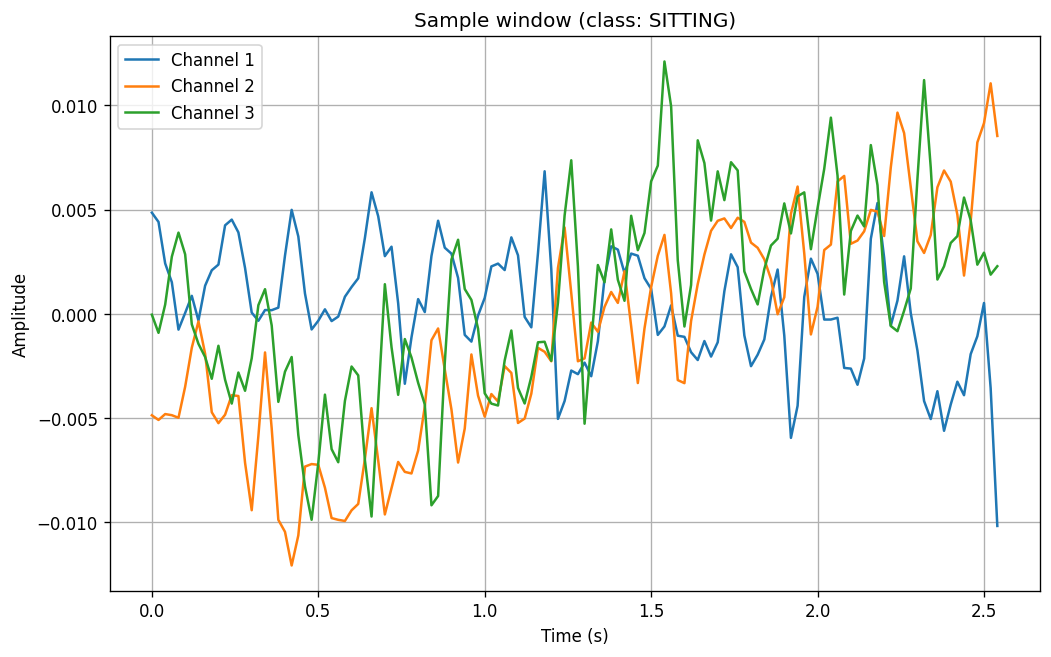

In [ ]:
sample_idx = 50
sig = X_train[sample_idx]  # [9, 128]
t = np.arange(sig.shape[1]) / 50.0  # 50Hz

plt.figure(figsize=(10,6))
for ch in range(3):  # first 3 channels
    plt.plot(t, sig[ch], label=f'Channel {ch+1}')
plt.title(f"Sample window (class: {classes[y_train[sample_idx]]})")
plt.xlabel("Time (s)"); plt.ylabel("Amplitude"); plt.legend(); plt.grid(True); plt.show()


How models take the data as input? Let's see.

In [ ]:
class HARDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return self.X.shape[0]
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = HARDataset(X_train, y_train)
test_ds  = HARDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False)

len(train_ds), len(test_ds)


(7352, 2947)

The custom dataset class shows how the model will see one sample and the Dataloader function feeds mininatches to the model.

Let's define a CNN+Linear Model.

In [ ]:
class CNN1D(nn.Module):
    def __init__(self, in_ch=9, n_classes=6):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv1d(in_ch, 32, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(2),  # 128 -> 64
        )
        self.block2 = nn.Sequential(
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(2),  # 64 -> 32
        )
        self.block3 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),  # 32 -> 16
        )

        #new convolutional layer
        self.newBlock = nn.Sequential(
            nn.Conv1d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),  # 16 -> 8
        )


        self.block4 = nn.Sequential(
            nn.Conv1d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),  # -> [B, 128, 1]
        )
        self.fc = nn.Linear(128, n_classes)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = x.squeeze(-1)   # [B, 128]
        return self.fc(x)

model = CNN1D().to(device)

dummy_input = torch.randn(128, 9, 128).to(device)
print(f"Input shape: {dummy_input.shape}")

x = model.block1(dummy_input)
print("After Block 1:", x.shape)

x = model.block2(x)
print("After Block 2:", x.shape)

x = model.block3(x)
print("After Block 3:", x.shape)

x = model.newBlock(x)
print("After New Layer:", x.shape)

x = model.block4(x)
print("After Block 4:", x.shape)
#print(model)

Input shape: torch.Size([128, 9, 128])
After Block 1: torch.Size([128, 32, 64])
After Block 2: torch.Size([128, 64, 32])
After Block 3: torch.Size([128, 128, 16])
After New Layer: torch.Size([128, 128, 8])
After Block 4: torch.Size([128, 128, 1])


Keep one thing in your mind. We need to have the model and data in the same device. 'cpu' or 'gpu'/'cuda'

Can you calculate the dimension after each block? That will be a task in your assignment.

How can we train our model? After random initialization, the model can make prediction. We calculate how far the model is from actual values with loss function and then update our model to minimize the loss value through the idea of gradient descent. After a few epochs, the model will learn to make better predictions. We can see the improvement by printing loss and accuracy value after each epoch. Validation loss and accuracy give us an idea how the model is generalizing i.e. how accurate its predictions are on unseen data.

## Cross-Entropy Loss

The cross-entropy loss for a single sample is defined as:



$
L = - \sum_{i=1}^{C} y_i \cdot \log(\hat{y}_i)
$



Where:
- C= number of classes  
- $y_i$ = true label (one-hot encoded; 1 if class i is correct, else 0)  
- $\hat{y}_i$ = predicted probability for class i (from softmax output)  

- If the true class is k, then only $y_k = 1$, so the loss simplifies to:


$
         L = - \log(\hat{y}_k)
$



- For a dataset of N samples, the average cross-entropy loss is:



$
L = - \frac{1}{N} \sum_{j=1}^{N} \sum_{i=1}^{C} y_{j,i} \cdot \log(\hat{y}_{j,i})
$




In [ ]:
def accuracy(pred, target):
    return (pred.argmax(1) == target).float().mean().item()

def evaluate(loader):
    model.eval()
    total_loss, total_acc, n = 0.0, 0.0, 0

    with torch.no_grad():
        for Xb, yb in loader:
            Xb, yb = Xb.to(device), yb.to(device)
            out = model(Xb)
            loss = F.cross_entropy(out, yb)
            total_loss += loss.item() * Xb.size(0)
            total_acc  += (out.argmax(1) == yb).sum().item()
            n += Xb.size(0)

    return total_loss/n, total_acc/n

opt = torch.optim.AdamW(model.parameters(), lr=3e-4)
epochs = 10
train_hist, val_hist = [], []

for ep in range(1, epochs+1):
    model.train()
    tot, n = 0.0, 0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        opt.zero_grad()
        out = model(Xb)
        loss = F.cross_entropy(out, yb)
        loss.backward()
        opt.step()
        tot += loss.item() * Xb.size(0); n += Xb.size(0)
    tr_loss = tot/n
    tr_acc  = evaluate(train_loader)[1]
    va_loss, va_acc = evaluate(test_loader)  # using test as validation for simplicity
    train_hist.append((tr_loss, tr_acc)); val_hist.append((va_loss, va_acc))
    print(f"Epoch {ep:02d}: train_loss={tr_loss:.4f} train_acc={tr_acc:.3f} | val_loss={va_loss:.4f} val_acc={va_acc:.3f}")


Epoch 01: train_loss=1.5222 train_acc=0.660 | val_loss=0.9558 val_acc=0.607
Epoch 02: train_loss=0.6340 train_acc=0.784 | val_loss=0.6792 val_acc=0.707
Epoch 03: train_loss=0.4479 train_acc=0.845 | val_loss=0.6376 val_acc=0.761
Epoch 04: train_loss=0.3390 train_acc=0.886 | val_loss=0.6034 val_acc=0.786
Epoch 05: train_loss=0.2693 train_acc=0.901 | val_loss=0.5320 val_acc=0.838
Epoch 06: train_loss=0.2305 train_acc=0.925 | val_loss=0.4705 val_acc=0.856
Epoch 07: train_loss=0.1941 train_acc=0.930 | val_loss=0.4417 val_acc=0.857
Epoch 08: train_loss=0.1778 train_acc=0.941 | val_loss=0.4003 val_acc=0.882
Epoch 09: train_loss=0.1646 train_acc=0.948 | val_loss=0.3760 val_acc=0.884
Epoch 10: train_loss=0.1546 train_acc=0.936 | val_loss=0.3634 val_acc=0.886


In model training tasks, it is almost customary to have a loss vs epoch plot. We can confirm if the model is overfitting or not.

***Remember what overfitting is.***

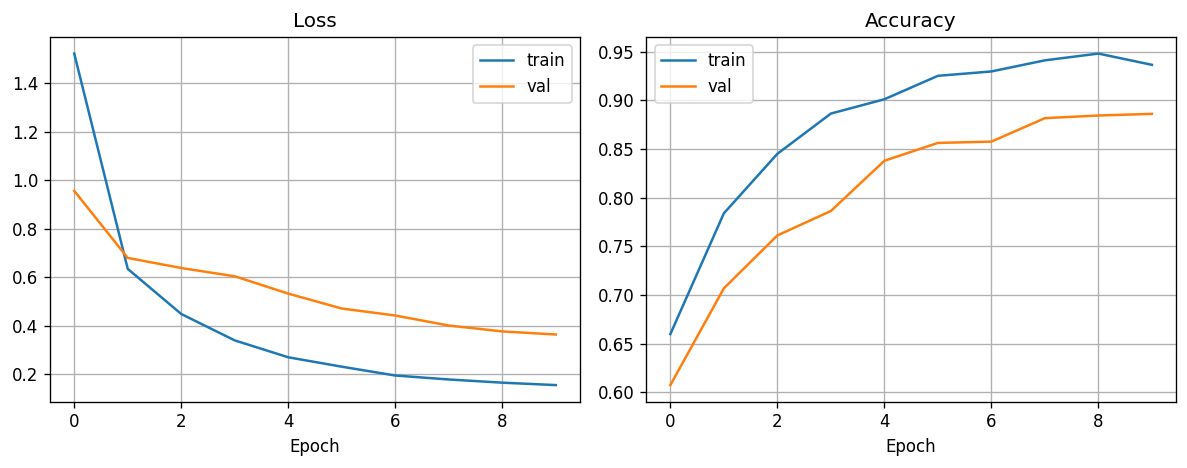

In [ ]:
tr_loss = [x[0] for x in train_hist]
tr_acc  = [x[1] for x in train_hist]
va_loss = [x[0] for x in val_hist]
va_acc  = [x[1] for x in val_hist]

fig, ax = plt.subplots(1,2, figsize=(10,4))
ax[0].plot(tr_loss, label='train'); ax[0].plot(va_loss, label='val')
ax[0].set_title("Loss"); ax[0].set_xlabel("Epoch"); ax[0].legend(); ax[0].grid(True)
ax[1].plot(tr_acc, label='train'); ax[1].plot(va_acc, label='val')
ax[1].set_title("Accuracy"); ax[1].set_xlabel("Epoch"); ax[1].legend(); ax[1].grid(True)
plt.tight_layout(); plt.show()


Do you think training for more epochs will help?

### Model Evaluation using Confusion Matrix and Classification Report

The **confusion matrix** is a useful visualization to understand how well the model performs across different activity classes.  
It summarizes the **correct predictions (diagonal elements)** and **misclassifications (off-diagonal elements)** made by the model for each class.


The **classification report** complements the confusion matrix by providing three key metrics for each class:

$
\text{Precision} = \frac{TP}{TP + FP}$


$\text{Recall} = \frac{TP}{TP + FN}$

$
\text{F1-score} = \frac{2 \times \text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}
$

Where:
- **TP** = True Positives (correctly predicted class samples)  
- **FP** = False Positives (incorrectly predicted as this class)  
- **FN** = False Negatives (missed samples of this class)

A high **F1-score** indicates both high precision and high recall, meaning the model performs consistently well for that class.


                    precision    recall  f1-score   support

           WALKING     0.9180    0.9476    0.9325       496
  WALKING_UPSTAIRS     0.8426    0.9321    0.8851       471
WALKING_DOWNSTAIRS     0.9022    0.8786    0.8902       420
           SITTING     0.8627    0.7169    0.7831       491
          STANDING     0.8024    0.8853    0.8418       532
            LAYING     1.0000    0.9497    0.9742       537

          accuracy                         0.8860      2947
         macro avg     0.8880    0.8850    0.8845      2947
      weighted avg     0.8886    0.8860    0.8852      2947



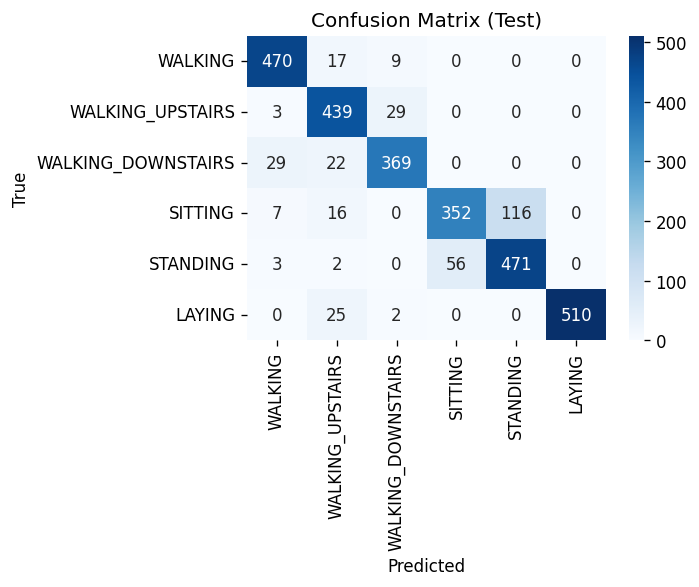

In [ ]:
def predict_all(loader):
    model.eval()
    preds, labels = [], []

    with torch.no_grad():
        for Xb, yb in loader:
            Xb = Xb.to(device)
            out = model(Xb)
            preds.append(out.argmax(1).cpu().numpy())
            # The classification report and confusion matrix can work only on
            # numpy arrays that are in cpu, so we have to move tensors to cpu.
            labels.append(yb.numpy())

    return np.concatenate(preds), np.concatenate(labels)

y_pred, y_true = predict_all(test_loader)

print(classification_report(y_true, y_pred, target_names=classes, digits=4))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title("Confusion Matrix (Test)"); plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout(); plt.show()


# **Analysis and Discussion**

No, the addition of the new convolutional layer (newBlock) did not improve performance.
The original model achieved 89.2% validation accuracy with an F1-score of 0.8918, while the modified model with the additional layer achieved only 88.6% validation accuracy with an F1-score of 0.8860.
This represents a decrease in accuracy.
Although I also changed the learning rate from 1e-3 to 3e-4 and take epochs 10 instead of 12.


Yes, I had to carefully adjust dimensions to maintain compatibility throughout the network. Taking 128 input channels from block3 and outputting 128 channels for the new block.

No, there is significant variation in performance across classes. LAYING remains the best-performing class with perfect 100% precision and 0.974 F1-score, while SITTING performs worst with 78.3% F1-score (down from 75.3% in the original model). The walking activities show mixed results: WALKING has 93.3% F1-score, WALKING_DOWNSTAIRS has 89.0%, and WALKING_UPSTAIRS dropped to 88.5%. STANDING improved slightly to 84.2% F1-score.
